<a href="https://colab.research.google.com/github/iliyasking/Iliyas/blob/main/GAN_Discriminator_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Firstly, Starting with downloading the "Face Dataset" directly inside the notebook so that the code remains fully independent.
The dataset is extracted locally, which means anyone running this notebook can access the data without manually uploading files.




In [ ]:
import os
import zipfile
import gdown

In [ ]:
file_id = "1JViIYbfzALiBSPI1PddP1AntDceA1Ylm"
output_zip = "dataset.zip"
!pip install -q gdown

In [ ]:
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_zip, quiet=False)

dataset_path = "dataset"
os.makedirs(dataset_path, exist_ok=True)

Downloading...
From (original): https://drive.google.com/uc?id=1JViIYbfzALiBSPI1PddP1AntDceA1Ylm
From (redirected): https://drive.google.com/uc?id=1JViIYbfzALiBSPI1PddP1AntDceA1Ylm&confirm=t&uuid=8bc070c6-6bba-430e-82de-7efc467739d1
To: /content/dataset.zip
100%|██████████| 297M/297M [00:03<00:00, 82.8MB/s]


In [ ]:
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(dataset_path)

print("Dataset downloaded and extracted successfully")

Dataset downloaded and extracted successfully




> After extracting the dataset, verifying the folder structure to ensure that the image files were extracted correctly and are accessible for further processing.



In [ ]:
import os
os.listdir(dataset_path)

['celeba_hq_256']

In [ ]:
os.listdir(dataset_path + "/celeba_hq_256")[:5]

['28057.jpg', '06565.jpg', '27482.jpg', '26604.jpg', '23694.jpg']



> Next, since PyTorch’s ImageFolder requires images to be stored inside a class folder, I organized all the face images into a single folder named faces. This step only restructures the dataset and does not alter the image content.



In [ ]:
import shutil

base_path = dataset_path + "/celeba_hq_256"
faces_path = base_path + "/faces"

os.makedirs(faces_path, exist_ok=True)

for file in os.listdir(base_path):
    if file.endswith(".jpg") or file.endswith(".png"):
        shutil.move(
            os.path.join(base_path, file),
            os.path.join(faces_path, file)
        )

print("Images moved into 'faces' folder")

Images moved into 'faces' folder




>Then, I loaded the dataset using PyTorch’s ImageFolder and applied the required transformations. The images were resized to 32×32 and normalized to the range −1,1 to match the output format of the Generator.



In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [ ]:
real_dataset = datasets.ImageFolder(
    root=dataset_path + "/celeba_hq_256",
    transform=transform
)

real_loader = DataLoader(real_dataset, batch_size=1, shuffle=True)
print("Total real images:", len(real_dataset))

Total real images: 30000




> Moving forward, I defined the Discriminator model using PyTorch. The Discriminator is a CNN-based network that takes a 3×32×32 RGB image as input and outputs a probability score indicating whether the image is real or fake.



In [ ]:
import torch
import torch.nn as nn


here i teach the model to tell whether an image is real or fake. It looks at an image and gives a score between the range 0 and 1, where 1 means the image is real and 0 means it is generated.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3,64,kernel_size=4,stride=2,padding=1),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(64,128,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(128,256,kernel_size=4,stride=2,padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Flatten(),
            nn.Linear(256*4*4,1),
            nn.Sigmoid()
        )

    #defining how the image passes through the network
    def forward(self, flag):
        return self.model(flag)

Creating the discriminator object now

In [ ]:
D = Discriminator()
D

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=4096, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

In [ ]:
'''
#testing with single image
x = torch.randn(1,3,32,32)
output = D(x)
print(output)
'''

'\n#testing with single image\nx = torch.randn(1,3,32,32)\noutput = D(x)\nprint(output)\n'

In [ ]:
'''
#testing with batch of images
x = torch.randn(4,3,32,32)
out = D(x)
print(out)
'''

'\n#testing with batch of images\nx = torch.randn(4,3,32,32)\nout = D(x)\nprint(out)\n'

In [ ]:
real_image, _ = next(iter(real_loader))
real_score = D(real_image)
print("Discriminator score for REAL image:", real_score.item())

Discriminator score for REAL image: 0.6831868290901184


From here, I included the generator module as defined by om in his code and The Generator produces fake images from random noise, ensuring that a new image is generated every time the code is executed.

After that, the same generated image is passed to the Discriminator, which outputs a score between 0 and 1 indicating how real or fake the image appears.

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, channels=3):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
      return self.net(x)

In [ ]:
#creating generator and discriminator objects and generating the fake image
G = Generator()
noise = torch.randn(1,100,1,1)
fake_image = G(noise)

**Visualizing Real vs Fake Image (Single Pair)**

Next, I visualized one real image from the dataset alongside one fake image generated by the Generator. Displaying them side by side helps in visually comparing real and generated samples.

In [ ]:
real_img = (real_image[0] + 1) / 2
real_img = real_img.permute(1, 2, 0).cpu().detach().numpy()

fake_img = (fake_image[0] + 1) / 2
fake_img = fake_img.permute(1, 2, 0).cpu().detach().numpy()

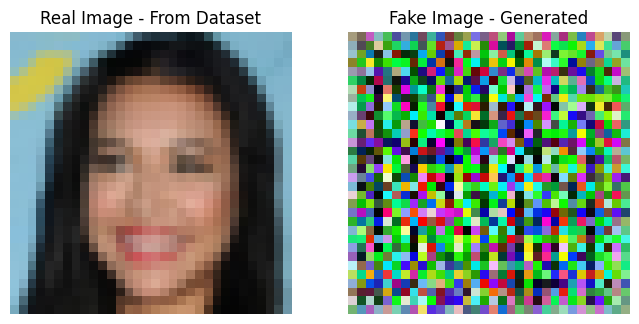

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(real_img)
plt.title("Real Image - From Dataset")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fake_img)
plt.title("Fake Image - Generated")
plt.axis("off")

plt.show()

Displaying Discriminator Scores for Single Images


In [ ]:
with torch.no_grad():
    real_score = D(real_image)
    fake_score = D(fake_image)

real_score_val = real_score.item()
fake_score_val = fake_score.item()

print("Discriminator Output Scores")
print("---------------------------")
print(f"Real Image Score : {real_score_val:.4f}")
print(f"Fake Image Score : {fake_score_val:.4f}")

Discriminator Output Scores
---------------------------
Real Image Score : 0.6832
Fake Image Score : 0.5144


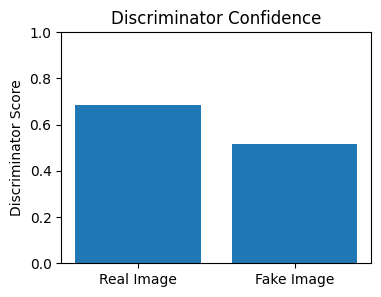

In [ ]:
import matplotlib.pyplot as plt

labels = ['Real Image', 'Fake Image']
scores = [real_score_val, fake_score_val]

plt.figure(figsize=(4,3))
plt.bar(labels, scores)
plt.ylim(0, 1)
plt.ylabel("Discriminator Score")
plt.title("Discriminator Confidence")

plt.show()

**Batch Processing of Images**

After that, I extended the process to multiple images by sampling a batch of real images from the dataset and generating a batch of fake images from random noise.

(here I have taken 8, can change it as required)

In [ ]:
batch_size = 8
real_images, _ = next(iter(
    DataLoader(real_dataset, batch_size=batch_size, shuffle=True)
))
noise = torch.randn(batch_size, 100, 1, 1)
fake_images = G(noise)

In [ ]:
#normalize back to [0,1] for display
real_imgs = (real_images + 1) / 2
fake_imgs = (fake_images + 1) / 2

real_imgs = real_imgs.permute(0, 2, 3, 1).cpu().detach().numpy()
fake_imgs = fake_imgs.permute(0, 2, 3, 1).cpu().detach().numpy()

**Grid Visualization of Multiple Images**

Then, I displayed multiple real and fake images in a grid format, with real images shown in the top row and fake images in the bottom row. This visualization highlights the diversity of the generated outputs.

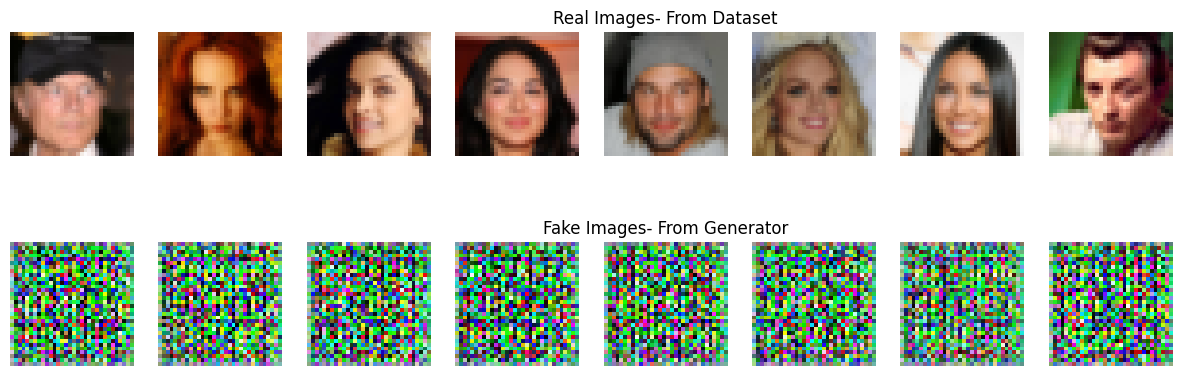

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# real images are printed on the top
for i in range(batch_size):
    plt.subplot(2, batch_size, i + 1)
    plt.imshow(real_imgs[i])
    plt.axis("off")
    if i == batch_size // 2:
        plt.title("Real Images- From Dataset")

# fake images on the botton row
for i in range(batch_size):
    plt.subplot(2, batch_size, batch_size + i + 1)
    plt.imshow(fake_imgs[i])
    plt.axis("off")
    if i == batch_size // 2:
        plt.title("Fake Images- From Generator")

plt.show()

In [ ]:
real_scores = D(real_images).view(-1)
fake_scores = D(fake_images).view(-1)

print("Discriminator scores for REAL images:")
print(real_scores)

print("\nDiscriminator scores for FAKE images:")
print(fake_scores)

Discriminator scores for REAL images:
tensor([0.5531, 0.5445, 0.6514, 0.5598, 0.5763, 0.5848, 0.6311, 0.6779],
       grad_fn=<ViewBackward0>)

Discriminator scores for FAKE images:
tensor([0.6850, 0.5511, 0.4033, 0.5654, 0.6698, 0.6405, 0.6186, 0.4824],
       grad_fn=<ViewBackward0>)


Finally, I visualized the Discriminator scores for multiple real and fake images to observe how the model responds to batch inputs and how its confidence varies across different samples.

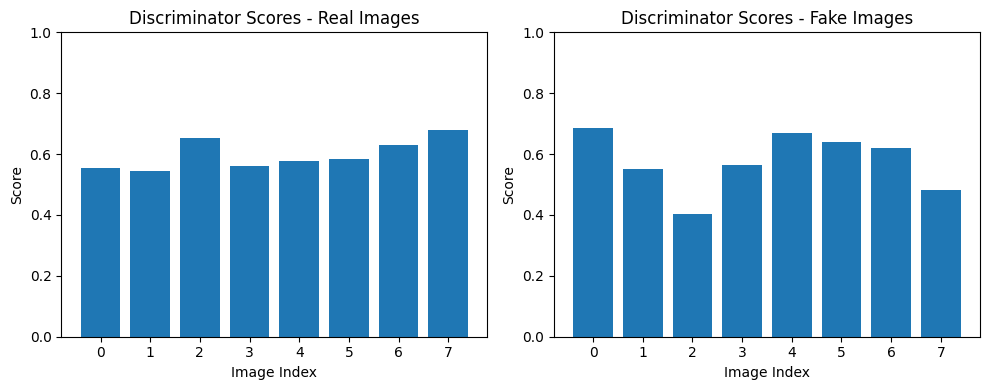

In [ ]:
import matplotlib.pyplot as plt

real_scores_np = real_scores.detach().cpu().numpy()
fake_scores_np = fake_scores.detach().cpu().numpy()

plt.figure(figsize=(10,4))

# real scores
plt.subplot(1,2,1)
plt.bar(range(batch_size), real_scores_np)
plt.ylim(0,1)
plt.title("Discriminator Scores - Real Images")
plt.xlabel("Image Index")
plt.ylabel("Score")

# fake scores
plt.subplot(1,2,2)
plt.bar(range(batch_size), fake_scores_np)
plt.ylim(0,1)
plt.title("Discriminator Scores - Fake Images")
plt.xlabel("Image Index")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

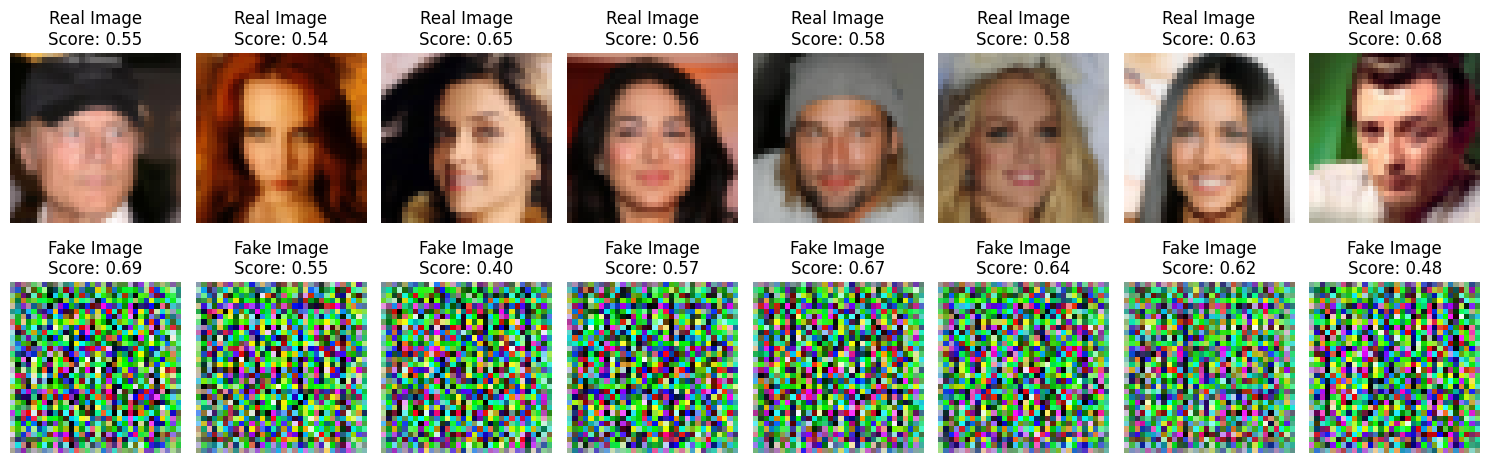

In [ ]:
plt.figure(figsize=(15,5))

# real images are printed on the top
for i in range(batch_size):
    plt.subplot(2, batch_size, i + 1)
    plt.imshow(real_imgs[i])
    plt.axis("off")
    plt.title(f"Real Image\nScore: {real_scores_np[i]:.2f}")

# fake images on the bottom row
for i in range(batch_size):
    plt.subplot(2, batch_size, batch_size + i + 1)
    plt.imshow(fake_imgs[i])
    plt.axis("off")
    plt.title(f"Fake Image\nScore: {fake_scores_np[i]:.2f}")

plt.tight_layout()
plt.show()